Loaded studentInfo:        32,593 rows
Loaded studentRegistration: 32,593 rows

studentRegistration columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']
  code_module code_presentation  id_student  date_registration  \
0         AAA             2013J       11391             -159.0   
1         AAA             2013J       28400              -53.0   
2         AAA             2013J       30268              -92.0   
3         AAA             2013J       31604              -52.0   
4         AAA             2013J       32885             -176.0   

   date_unregistration  
0                  NaN  
1                  NaN  
2                 12.0  
3                  NaN  
4                  NaN   

D0: Inspecting date_unregistration column...

  Total student-course rows        : 32,593
  Withdrew (have unregistration date): 10,072 (30.9%)
  Did not withdraw                 : 22,521 (69.1%)
  Pre-course withdrawals (day < 0) : 2,678

  date_

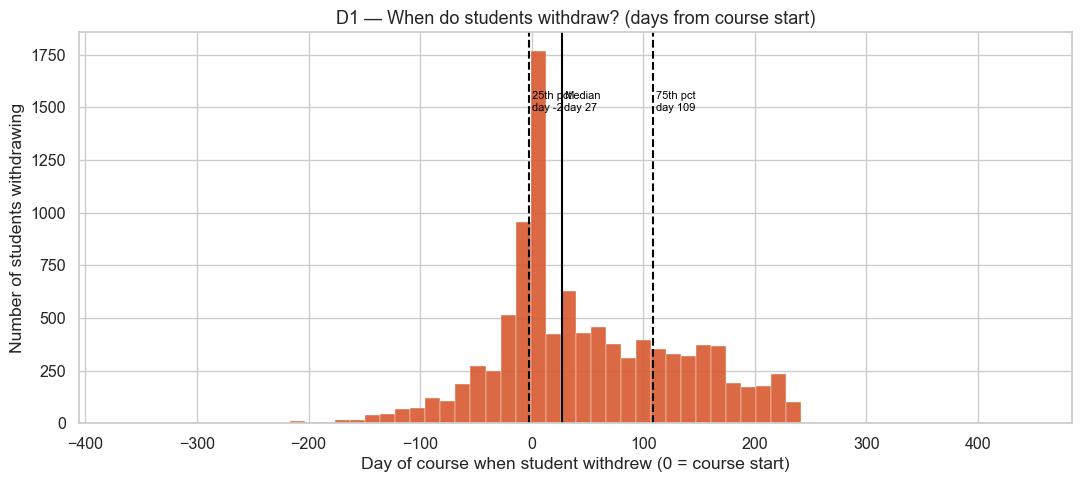

  Saved → ./outputs/block_d/D1_dropout_timing_histogram.png
  Median dropout day: 27
  25th percentile   : day -2
  75th percentile   : day 109

D2: Cumulative dropout curve...


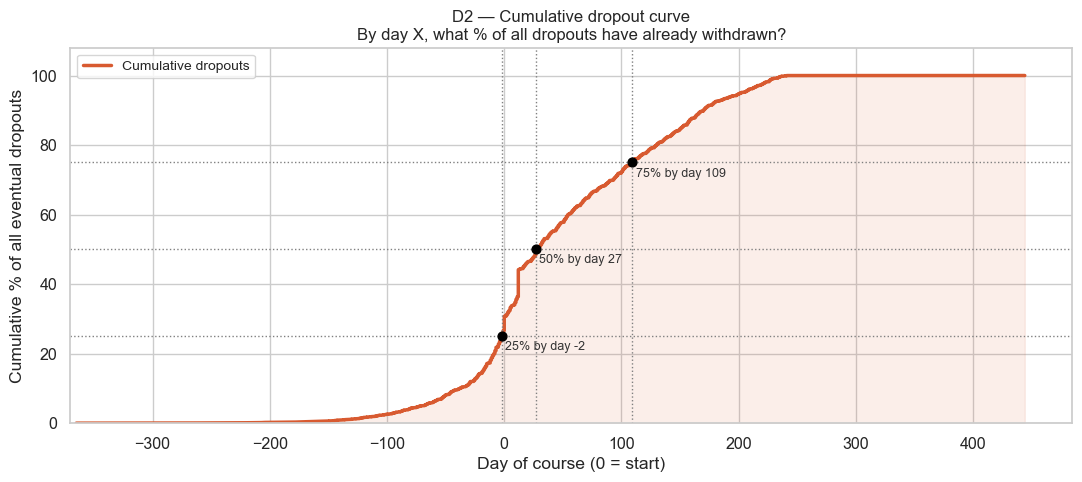

  Saved → ./outputs/block_d/D2_cumulative_dropout_curve.png

D3: Dropout timing by course module...


C:\Users\leade\AppData\Local\Temp\ipykernel_14492\1017431459.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\leade\AppData\Local\Temp\ipykernel_14492\1017431459.py:220: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


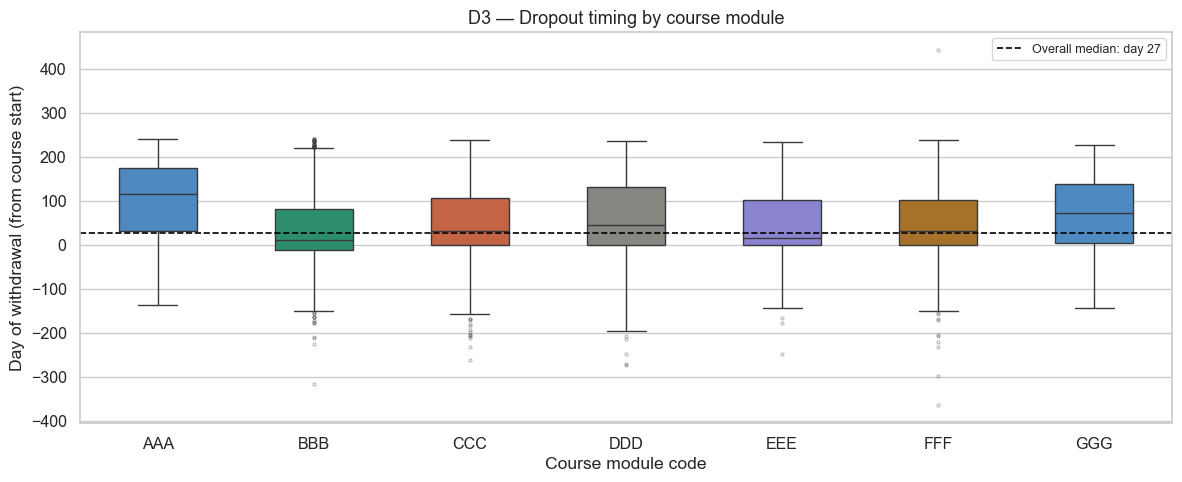

  Saved → ./outputs/block_d/D3_dropout_timing_by_module.png

  Median withdrawal day per module:
code_module
BBB     12
EEE     16
FFF     31
CCC     32
DDD     46
GGG     73
AAA    116

D4: Dropout timing by age band...


C:\Users\leade\AppData\Local\Temp\ipykernel_14492\1017431459.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\leade\AppData\Local\Temp\ipykernel_14492\1017431459.py:271: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
C:\Users\leade\AppData\Local\Temp\ipykernel_14492\1017431459.py:293: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


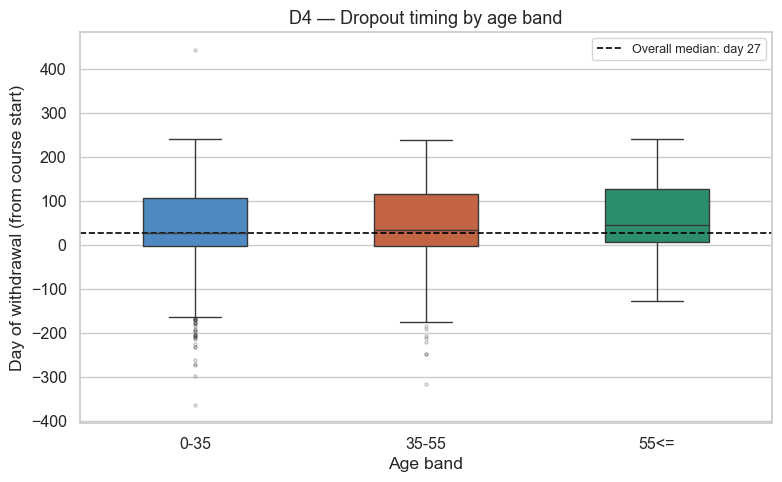

  Saved → ./outputs/block_d/D4_dropout_timing_by_age.png

  Median withdrawal day per age band:
age_band
0-35     27
35-55    34
55<=     46

D5: Early vs late dropout split...


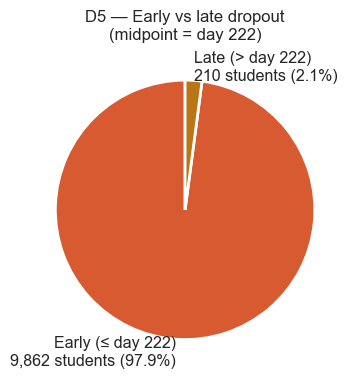

  Saved → ./outputs/block_d/D5_early_vs_late_dropout.png

  Course approximate length : 444 days
  Midpoint                  : day 222
  Early dropout share       : 97.9%
  Late dropout share        : 2.1%

BLOCK D COMPLETE — Timing Insights

  Total withdrawn students      : 10,072
  Median withdrawal day         : 27
  25th percentile withdrawal day: -2
  75th percentile withdrawal day: 109

  Key insight for the early warning system:
    → 50% of dropouts leave by day 27.
    → A model that scores students by day -1 could
      flag students BEFORE half of them actually withdraw.

  Charts saved to: ./outputs/block_d/
    D1_dropout_timing_histogram.png
    D2_cumulative_dropout_curve.png
    D3_dropout_timing_by_module.png
    D4_dropout_timing_by_age.png
    D5_early_vs_late_dropout.png

─────────────────────────────────────────────────
Phase 2 EDA is now COMPLETE!
Next → Phase 3: Statistical Analysis
  (chi-square tests, t-tests, logistic regression)
─────────────────────────────

In [1]:
"""
=============================================================
Phase 2 — Block D: Registration & Dropout Timing
=============================================================
Goal: Understand WHEN students drop out during the course.

This is the most critical block for building an EARLY WARNING system.
If most dropouts happen in the first 100 days, we know our model
needs to generate predictions by day 50–80 to be useful for intervention.

Key column: studentRegistration.date_unregistration
  - Measured in DAYS from the start of the course presentation
  - NaN = student did NOT withdraw (they passed, failed, or got a distinction)
  - Negative values = student unregistered BEFORE the course started

We use: studentRegistration.csv (timing data)
         studentInfo.csv         (demographic data for breakdown plots)
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/block_d/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load data ─────────────────────────────────────────────────
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
sr = pd.read_csv(DATA_PATH + 'studentRegistration.csv')

si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

print(f"Loaded studentInfo:        {si.shape[0]:,} rows")
print(f"Loaded studentRegistration: {sr.shape[0]:,} rows")
print(f"\nstudentRegistration columns: {list(sr.columns)}")
print(sr.head(), "\n")


# =============================================================
# D0: Inspect the registration table
# =============================================================
# Before plotting, understand what date_unregistration contains.

print("D0: Inspecting date_unregistration column...\n")

# How many students withdrew (have a non-null unregistration date)?
n_withdrew      = sr['date_unregistration'].notna().sum()
n_total         = len(sr)
n_did_not_leave = sr['date_unregistration'].isna().sum()

print(f"  Total student-course rows        : {n_total:,}")
print(f"  Withdrew (have unregistration date): {n_withdrew:,} ({n_withdrew/n_total*100:.1f}%)")
print(f"  Did not withdraw                 : {n_did_not_leave:,} ({n_did_not_leave/n_total*100:.1f}%)")

# Check for negative values (pre-course withdrawals)
n_negative = (sr['date_unregistration'] < 0).sum()
print(f"  Pre-course withdrawals (day < 0) : {n_negative:,}")

# Summary stats on withdrawal timing
print("\n  date_unregistration summary stats (withdrawn students only):")
withdrawn_days = sr[sr['date_unregistration'].notna()]['date_unregistration']
print(withdrawn_days.describe().round(1).to_string())
print()


# =============================================================
# D1: Histogram — When do dropouts happen?
# =============================================================
# A histogram of unregistration days shows us the distribution
# of dropout timing across the course calendar.
#
# Key question: Is there a spike early in the course, or is dropout
# spread evenly throughout?

print("D1: Histogram of dropout timing...")

# Filter to withdrawn students only
withdrawn = sr[sr['date_unregistration'].notna()].copy()

# Calculate key percentile days for annotation
p25_day  = withdrawn['date_unregistration'].quantile(0.25)
p50_day  = withdrawn['date_unregistration'].quantile(0.50)   # median
p75_day  = withdrawn['date_unregistration'].quantile(0.75)

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    withdrawn['date_unregistration'],
    bins=60,                       # 60 bins gives good granularity
    color=COLORS['coral'],
    edgecolor='white',
    linewidth=0.3,
    alpha=0.9
)

# Annotate the 25th, 50th (median), and 75th percentile days
for day, label, style in [
    (p25_day, f"25th pct\nday {int(p25_day)}", '--'),
    (p50_day, f"Median\nday {int(p50_day)}",   '-'),
    (p75_day, f"75th pct\nday {int(p75_day)}", '--'),
]:
    ax.axvline(day, color='black', linestyle=style, linewidth=1.5)
    ax.text(day + 2, ax.get_ylim()[1] * 0.85, label,
            fontsize=8, color='black', va='top')

ax.set_title(
    "D1 — When do students withdraw? (days from course start)",
    fontsize=13
)
ax.set_xlabel("Day of course when student withdrew (0 = course start)")
ax.set_ylabel("Number of students withdrawing")

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D1_dropout_timing_histogram.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}")
print(f"  Median dropout day: {int(p50_day)}")
print(f"  25th percentile   : day {int(p25_day)}")
print(f"  75th percentile   : day {int(p75_day)}\n")


# =============================================================
# D2: Cumulative dropout curve
# =============================================================
# The histogram shows WHEN, but a cumulative curve shows
# "by day X, what % of all eventual dropouts have already left?"
#
# This is the key chart for designing an intervention strategy.
# Example reading: "By day 100, 60% of dropouts have already withdrawn."
# That means: if we can identify at-risk students by day 80, we can
# reach the majority of dropouts before they actually leave.

print("D2: Cumulative dropout curve...")

# Sort withdrawal days and compute the running cumulative percentage
sorted_days     = withdrawn['date_unregistration'].sort_values().reset_index(drop=True)
cumulative_pct  = (sorted_days.index + 1) / len(sorted_days) * 100

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(sorted_days, cumulative_pct,
        color=COLORS['coral'], linewidth=2.5, label='Cumulative dropouts')

# Shade the area under the curve for visual clarity
ax.fill_between(sorted_days, cumulative_pct,
                alpha=0.1, color=COLORS['coral'])

# Draw reference lines at 25%, 50%, and 75% milestones
for pct_target in [25, 50, 75]:
    # Find which day corresponds to this cumulative % of dropouts
    idx = int(len(sorted_days) * pct_target / 100) - 1
    day = int(sorted_days.iloc[idx])
    ax.axhline(pct_target, color='gray', linestyle=':', linewidth=1)
    ax.axvline(day,        color='gray', linestyle=':', linewidth=1)
    ax.scatter(day, pct_target, color='black', zorder=5, s=40)
    ax.text(day + 3, pct_target - 4,
            f"{pct_target}% by day {day}",
            fontsize=9, color='#333333')

ax.set_title(
    "D2 — Cumulative dropout curve\n"
    "By day X, what % of all dropouts have already withdrawn?",
    fontsize=12
)
ax.set_xlabel("Day of course (0 = start)")
ax.set_ylabel("Cumulative % of all eventual dropouts")
ax.set_ylim(0, 108)
ax.set_xlim(left=sorted_days.min() - 5)
ax.legend(fontsize=10)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D2_cumulative_dropout_curve.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# D3: Dropout timing by course module
# =============================================================
# Different courses might have different timing patterns.
# Some might see early dropout (students realise it's not for them),
# others late dropout (students hit a difficult assessment and give up).
#
# We merge studentRegistration with studentInfo to get module codes.

print("D3: Dropout timing by course module...")

# Merge registration timing data with studentInfo to get module codes
# We join on id_student, code_module, and code_presentation
sr_info = sr.merge(
    si[['id_student', 'code_module', 'code_presentation', 'dropout']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

# Filter to withdrawn students only
withdrawn_by_module = sr_info[sr_info['date_unregistration'].notna()]

fig, ax = plt.subplots(figsize=(12, 5))

# Box plot: one box per course module showing spread of withdrawal days
# This lets us see both the median and spread for each module
sns.boxplot(
    data=withdrawn_by_module,
    x='code_module',
    y='date_unregistration',
    palette=list(COLORS.values()),
    ax=ax,
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

# Reference line at the overall median dropout day
ax.axhline(p50_day, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall median: day {int(p50_day)}')

ax.set_title("D3 — Dropout timing by course module", fontsize=13)
ax.set_xlabel("Course module code")
ax.set_ylabel("Day of withdrawal (from course start)")
ax.legend(fontsize=9)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D3_dropout_timing_by_module.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")

# Print median withdrawal day per module
print("  Median withdrawal day per module:")
median_by_module = (
    withdrawn_by_module.groupby('code_module')['date_unregistration']
    .median()
    .sort_values()
    .round(0)
    .astype(int)
)
print(median_by_module.to_string())
print()


# =============================================================
# D4: Dropout timing by age band
# =============================================================
# Do older students drop out earlier in the course (perhaps realising
# sooner it doesn't fit their schedule), or later?
# Merge timing data with demographics from studentInfo.

print("D4: Dropout timing by age band...")

age_order = ['0-35', '35-55', '55<=']

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=withdrawn_by_module,       # already has age info from the merge above
    x='code_module',                # use module as sub-groups for context
    y='date_unregistration',
    ax=ax,
    palette=list(COLORS.values()),
    width=0.5,
)

# Actually: let's do this by age band properly using studentInfo merge
withdrawn_age = sr.merge(
    si[['id_student', 'code_module', 'code_presentation', 'age_band']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)
withdrawn_age = withdrawn_age[withdrawn_age['date_unregistration'].notna()]
withdrawn_age = withdrawn_age[withdrawn_age['age_band'].isin(age_order)]

plt.close()   # close the incomplete plot above

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=withdrawn_age,
    x='age_band',
    y='date_unregistration',
    order=age_order,
    palette=[COLORS['blue'], COLORS['coral'], COLORS['teal']],
    ax=ax,
    width=0.45,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)

ax.axhline(p50_day, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall median: day {int(p50_day)}')

ax.set_title("D4 — Dropout timing by age band", fontsize=13)
ax.set_xlabel("Age band")
ax.set_ylabel("Day of withdrawal (from course start)")
ax.legend(fontsize=9)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D4_dropout_timing_by_age.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")

print("  Median withdrawal day per age band:")
print(withdrawn_age.groupby('age_band')['date_unregistration']
      .median().round(0).astype(int).reindex(age_order).to_string())
print()


# =============================================================
# D5: Early vs late dropout split
# =============================================================
# For the early warning system, we need to define "early" vs "late" dropout.
# We'll use the course midpoint as the dividing line.
# Students who withdraw in the first half = early dropout (hardest to save
# but most impactful to catch). Students in the second half = late dropout.

print("D5: Early vs late dropout split...")

# Estimate course length from max withdrawal day + buffer
max_day       = withdrawn['date_unregistration'].max()
course_length = max_day   # approximate: the last withdrawal day ≈ end of course
midpoint      = course_length / 2

# Label each withdrawn student as early or late dropout
withdrawn_labelled = withdrawn.copy()
withdrawn_labelled['dropout_timing'] = np.where(
    withdrawn_labelled['date_unregistration'] <= midpoint,
    f'Early (≤ day {int(midpoint)})',
    f'Late (> day {int(midpoint)})'
)

timing_counts = withdrawn_labelled['dropout_timing'].value_counts()
timing_pcts   = timing_counts / len(withdrawn_labelled) * 100

fig, ax = plt.subplots(figsize=(6, 4))

ax.pie(
    timing_counts.values,
    labels=[f"{k}\n{v:,} students ({timing_pcts[k]:.1f}%)"
            for k, v in timing_counts.items()],
    colors=[COLORS['coral'], COLORS['amber']],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax.set_title(
    f"D5 — Early vs late dropout\n(midpoint = day {int(midpoint)})",
    fontsize=12
)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "D5_early_vs_late_dropout.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}")
print(f"\n  Course approximate length : {int(course_length)} days")
print(f"  Midpoint                  : day {int(midpoint)}")
print(f"  Early dropout share       : {timing_pcts.iloc[0]:.1f}%")
print(f"  Late dropout share        : {timing_pcts.iloc[1]:.1f}%\n")


# =============================================================
# BLOCK D SUMMARY
# =============================================================
print("=" * 55)
print("BLOCK D COMPLETE — Timing Insights")
print("=" * 55)
print(f"""
  Total withdrawn students      : {len(withdrawn):,}
  Median withdrawal day         : {int(p50_day)}
  25th percentile withdrawal day: {int(p25_day)}
  75th percentile withdrawal day: {int(p75_day)}

  Key insight for the early warning system:
    → 50% of dropouts leave by day {int(p50_day)}.
    → A model that scores students by day {int(p25_day*0.7):.0f} could
      flag students BEFORE half of them actually withdraw.

  Charts saved to: {OUTPUT_PATH}
    D1_dropout_timing_histogram.png
    D2_cumulative_dropout_curve.png
    D3_dropout_timing_by_module.png
    D4_dropout_timing_by_age.png
    D5_early_vs_late_dropout.png

─────────────────────────────────────────────────
Phase 2 EDA is now COMPLETE!
Next → Phase 3: Statistical Analysis
  (chi-square tests, t-tests, logistic regression)
─────────────────────────────────────────────────
""")